# Exercise 2: Statistical Visualization

name:Sarah Mohammed

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)


A Figure is the overall window or canvas that contains everything you see, while an Axes is the specific area where the data is actually plotted (the individual plot with its x and y axes).
 A single figure can hold multiple axes.


**2.** Name the three figure-level functions in `seaborn`.


relplot(): For relational plots (like scatter or line plots)

displot(): For distribution plots (like histograms or KDE)

catplot(): For categorical plots (like bar or box plots)


**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?


A Histogram is used to show the distribution of numerical data (by grouping numbers into bins), whereas a Barplot is used to compare values across different groups of categorical data.

## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

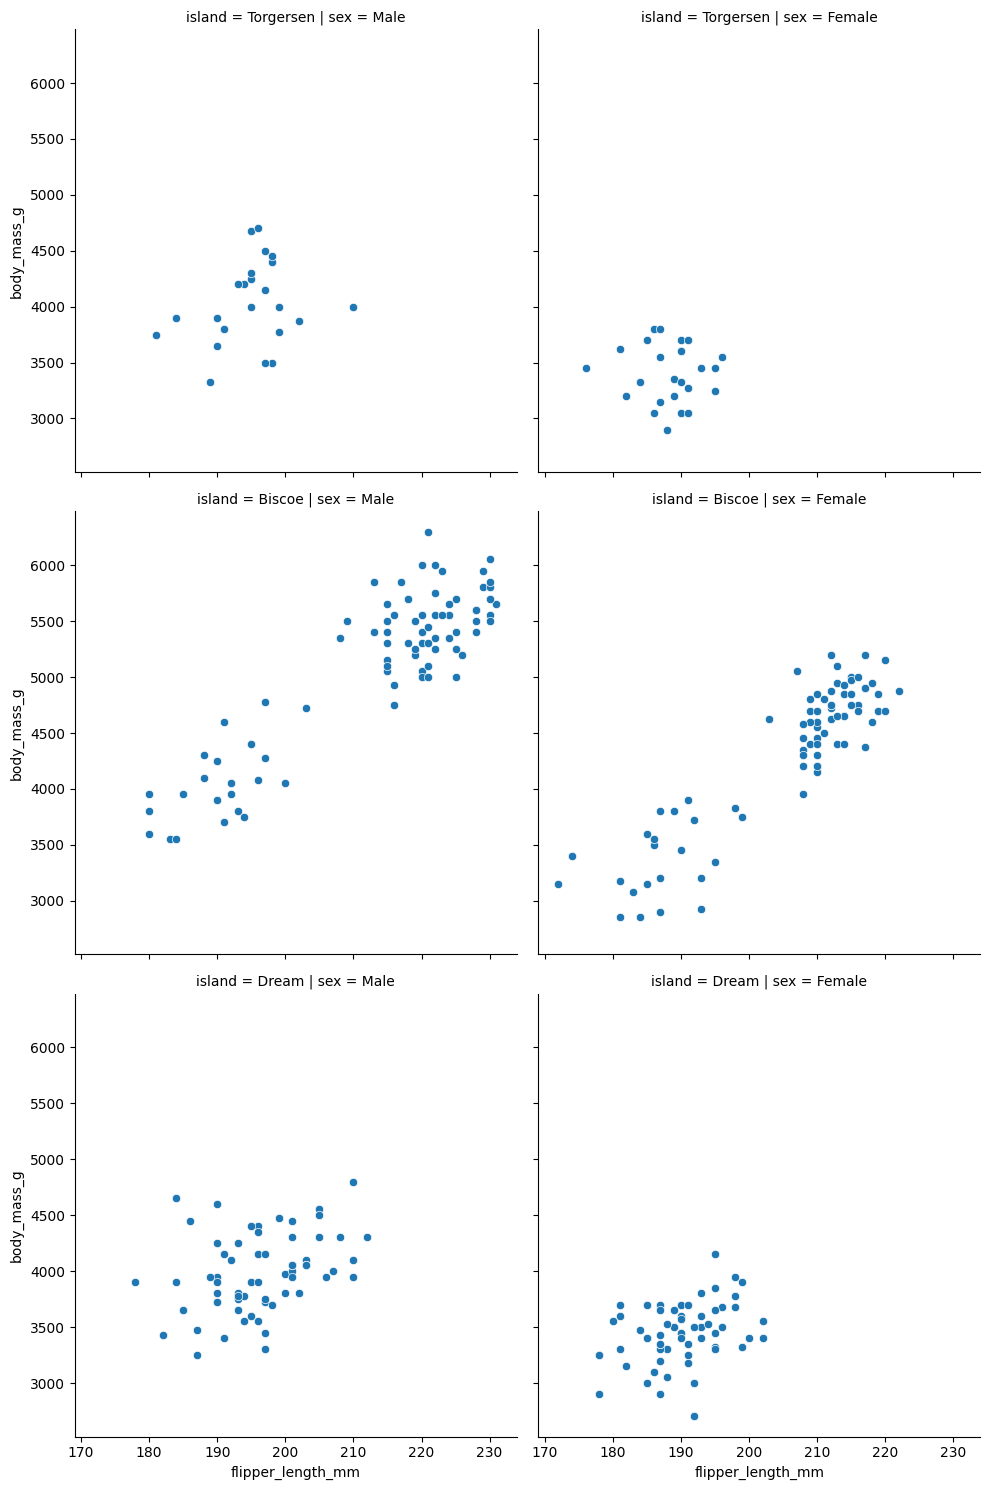

In [4]:
sns.relplot(
    data=df, 
    x="flipper_length_mm", 
    y="body_mass_g", 
    col="sex",    
    row="island"
)

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

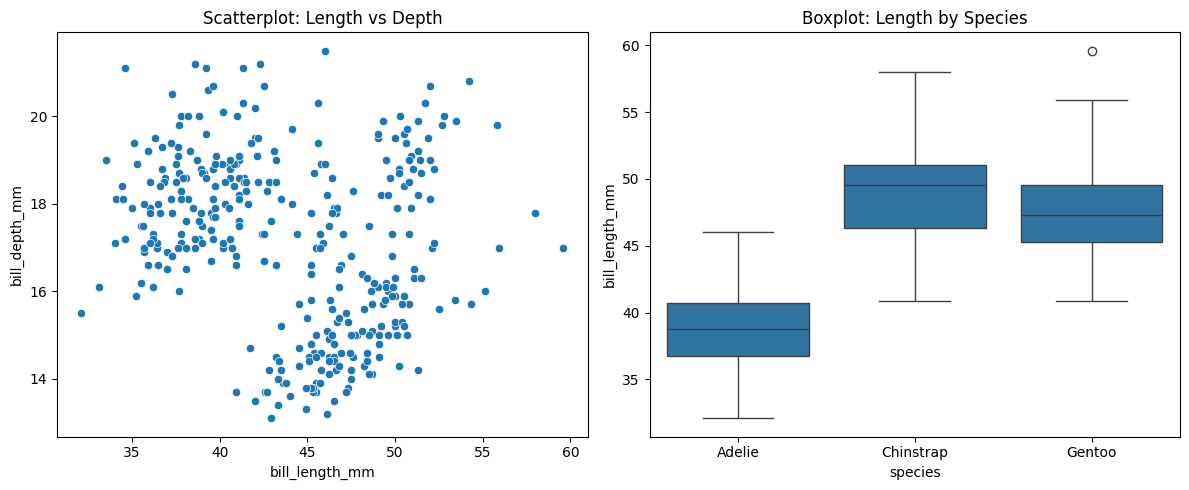

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", ax=ax1)
ax1.set_title("Scatterplot: Length vs Depth")

sns.boxplot(data=df, x="species", y="bill_length_mm", ax=ax2)
ax2.set_title("Boxplot: Length by Species")

plt.tight_layout()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

<Axes: xlabel='species', ylabel='flipper_length_mm'>

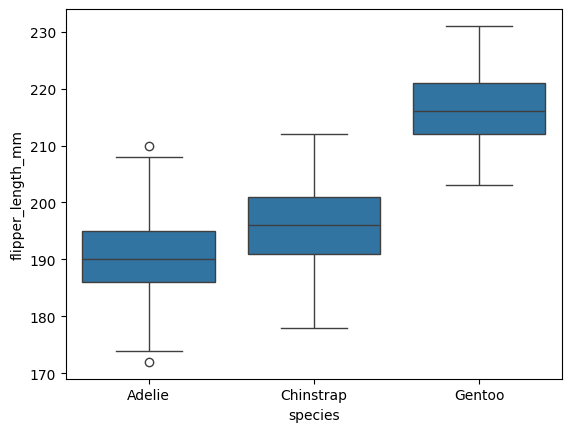

In [5]:
sns.boxplot(data=df, x="species", y="flipper_length_mm")



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



<Axes: xlabel='body_mass_g', ylabel='Count'>

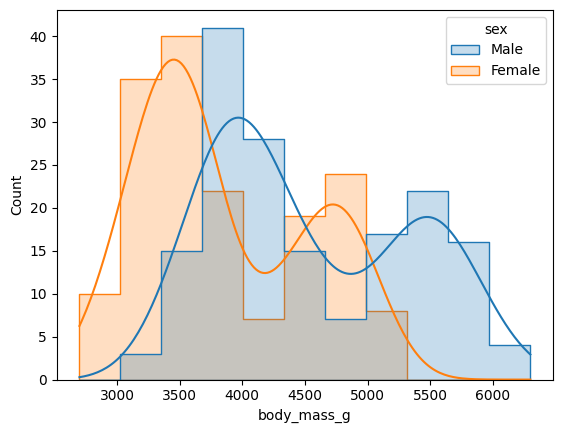

In [6]:
sns.histplot(data=df, x="body_mass_g", hue="sex", kde=True, element="step")



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



<Axes: xlabel='body_mass_g', ylabel='Proportion'>

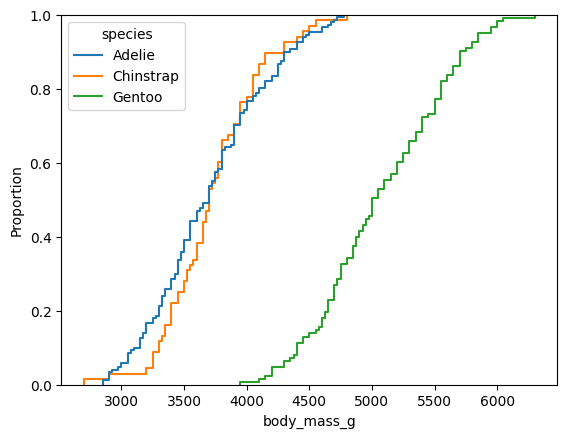

In [7]:
sns.ecdfplot(data=df, x="body_mass_g", hue="species")



*(Your interpretation here)*



**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

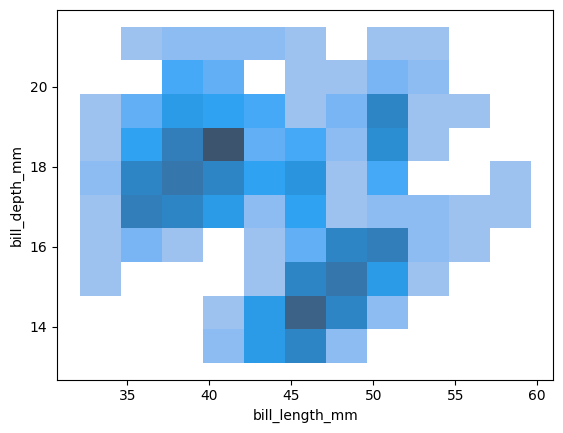

In [8]:
sns.histplot(data=df, x="bill_length_mm", y="bill_depth_mm")

## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

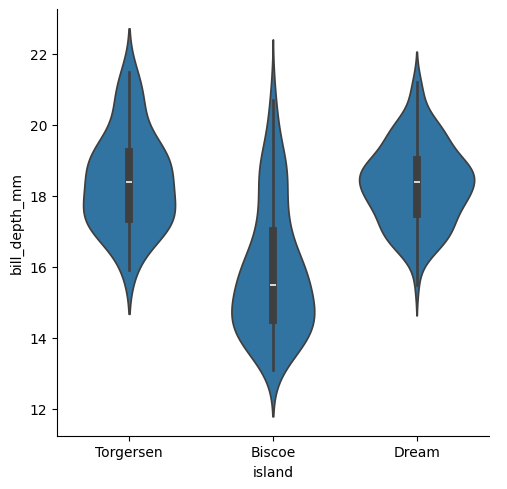

In [10]:
sns.catplot(data=df, x="island", y="bill_depth_mm", kind="violin")

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

Text(0.5, 1.0, 'Penguin Count by Island and Species')

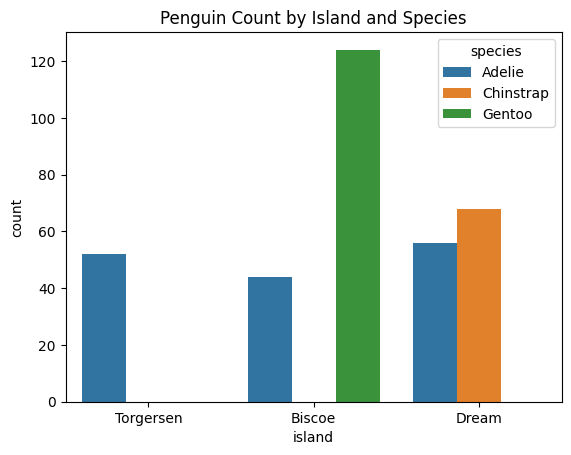

In [14]:
sns.countplot(data=df, x="island", hue="species")
plt.title("Penguin Count by Island and Species")

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

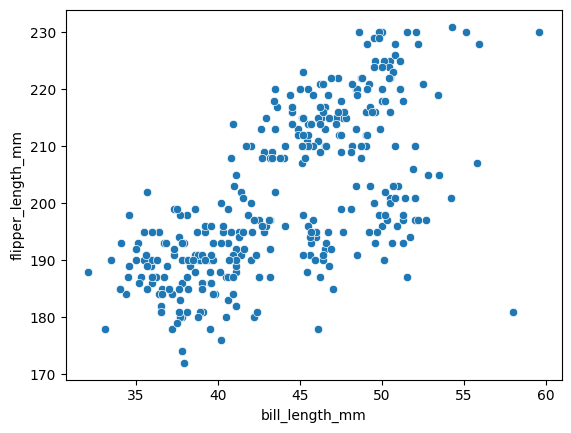

In [15]:
sns.scatterplot(data=df, x="bill_length_mm", y="flipper_length_mm")

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

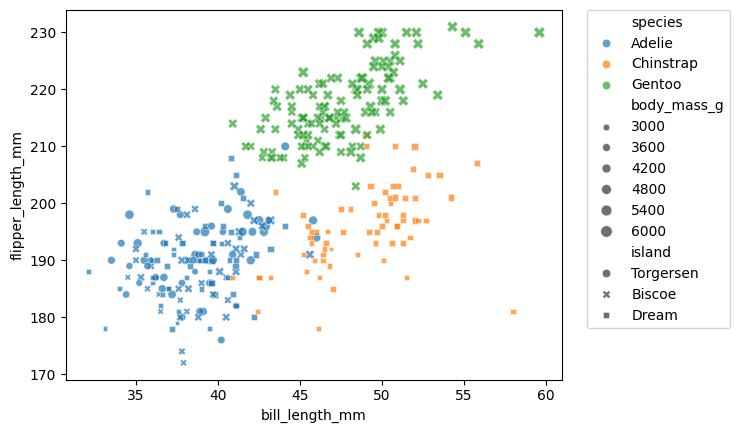

In [16]:
sns.scatterplot(
    data=df, 
    x="bill_length_mm", 
    y="flipper_length_mm", 
    hue="species",       
    style="island",     
    size="body_mass_g", 
    alpha=0.7           
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)